In [9]:
# Setup — imports and paths
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.config import config
from src.data_loader import DataLoader
from src.detectors import Pipeline
from src.evaluation import Evaluator
from src.utils import extract_if_needed, save_versioned_submission

config.paths.base_dir = project_root
config.paths.data_raw_dir = project_root / "data" / "raw"
config.paths.data_processed_dir = project_root / "data" / "processed"
config.paths.submissions_dir = project_root / "submissions"

config.paths.data_raw_dir.mkdir(parents=True, exist_ok=True)
config.paths.data_processed_dir.mkdir(parents=True, exist_ok=True)
config.paths.submissions_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Setup complete: sr={config.audio.sample_rate}, method={config.onset.method}")

Project root: c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge
Setup complete: sr=22050, method=superflux


In [10]:
# Extract datasets
datasets = [
    ("train", config.paths.data_raw_dir / "train.zip", config.paths.data_processed_dir / "train"),
    ("test", config.paths.data_raw_dir / "test.zip", config.paths.data_processed_dir / "test"),
    ("extra_onsets", config.paths.data_raw_dir / "train_extra_onsets.zip", config.paths.data_processed_dir / "train_extra_onsets"),
    ("extra_tempobeats", config.paths.data_raw_dir / "train_extra_tempobeats.zip", config.paths.data_processed_dir / "train_extra_tempobeats"),
]

for name, zip_path, dest in datasets:
    if zip_path.exists():
        extracted = extract_if_needed(zip_path, dest)
        print(f"{name}: {'extracted' if extracted else 'already exists'}")
    else:
        print(f"{name}: ZIP not found")

train: already exists
test: already exists
extra_onsets: already exists
extra_tempobeats: already exists


In [11]:
# Load all data
loader = DataLoader()

train_dir = config.paths.data_processed_dir / "train"
train_data = loader.load_train(train_dir)
print(f"Training: {len(train_data)} files")

extra_onsets_dir = config.paths.data_processed_dir / "train_extra_onsets"
extra_onsets = loader.load_extra_onsets(extra_onsets_dir) if extra_onsets_dir.exists() else {}
print(f"Extra onsets: {len(extra_onsets)} files")

extra_tempobeats_dir = config.paths.data_processed_dir / "train_extra_tempobeats"
extra_tempobeats = loader.load_extra_tempobeats(extra_tempobeats_dir) if extra_tempobeats_dir.exists() else {}
print(f"Extra tempo/beats: {len(extra_tempobeats)} files")

all_train = {**train_data, **extra_onsets, **extra_tempobeats}
print(f"Total training: {len(all_train)} files")

test_dir = config.paths.data_processed_dir / "test"
test_data = loader.load_test(test_dir)
print(f"Test: {len(test_data)} files")

Loading training data: 100%|██████████| 127/127 [00:00<00:00, 1531.49it/s]


Training: 127 files


Loading extra onsets: 100%|██████████| 150/150 [00:00<00:00, 4302.17it/s]


Extra onsets: 150 files


Loading extra tempo/beats: 100%|██████████| 696/696 [00:00<00:00, 4309.94it/s]


Extra tempo/beats: 696 files
Total training: 973 files


Loading test data: 100%|██████████| 50/50 [00:00<00:00, 174037.51it/s]

Test: 50 files


In [12]:
# Parameters — set all config values here only
config.onset.threshold = 0.011
config.onset.method = "superflux"
config.audio.superflux_gamma = 200.0
config.audio.superflux_mu = 3

pipeline = Pipeline()
print(f"Parameters: threshold={config.onset.threshold}, method={config.onset.method}, "
      f"hop={config.audio.onset_hop_length}, gamma={config.audio.superflux_gamma}, mu={config.audio.superflux_mu}")

Parameters: threshold=0.011, method=superflux, hop=256, gamma=200.0, mu=3


In [13]:
# Validate — evaluate on full training set (127 files)
import mir_eval

val_items = train_data  # all 127 annotated files

val_predictions = {}
for stem, info in val_items.items():
    y, sr = loader.load_audio(info['wav'])
    if y is None:
        continue
    onsets, beats, tempos = pipeline.process_file(y, sr)
    val_predictions[stem] = {
        'onsets': onsets.tolist(),
        'beats': beats.tolist(),
        'tempo': tempos
    }

onset_scores, beat_scores, tempo_scores = [], [], []

for stem, gt in val_items.items():
    if stem not in val_predictions:
        continue
    pred = val_predictions[stem]

    if gt.get('onsets') and pred.get('onsets'):
        f, _, _ = mir_eval.onset.f_measure(
            np.array(gt['onsets']), np.array(pred['onsets']), window=0.05
        )
        onset_scores.append(f)

    if gt.get('beats') and pred.get('beats'):
        f = mir_eval.beat.f_measure(np.array(gt['beats']), np.array(pred['beats']))
        beat_scores.append(f)

    if gt.get('tempo') and pred.get('tempo'):
        gt_tempo = gt['tempo']
        if len(gt_tempo) == 1:
            ref_tempi = np.array([gt_tempo[0] / 2, gt_tempo[0]])
            ref_weight = 0.5
        elif len(gt_tempo) == 2:
            ref_tempi = np.array(gt_tempo)
            ref_weight = 0.5
        elif len(gt_tempo) >= 3:
            ref_tempi = np.array(gt_tempo[:2])
            ref_weight = gt_tempo[2]
        else:
            continue
        est_tempi = np.array(pred['tempo'][:2])
        try:
            p_score = mir_eval.tempo.detection(ref_tempi, ref_weight, est_tempi, tol=0.08)
            tempo_scores.append(p_score)
        except Exception:
            pass

print("VALIDATION RESULTS (127 files)")
print(f"  Onset F1:  {np.mean(onset_scores):.4f}  ({len(onset_scores)} files)")
print(f"  Beat F1:   {np.mean(beat_scores):.4f}  ({len(beat_scores)} files)")
print(f"  Tempo:     {np.mean(tempo_scores):.4f}  ({len(tempo_scores)} files)")
overall = (np.mean(onset_scores) + np.mean(beat_scores) + np.mean(tempo_scores)) / 3
print(f"  MEAN:      {overall:.4f}")

VALIDATION RESULTS (127 files)
  Onset F1:  0.7866  (127 files)
  Beat F1:   0.4960  (127 files)
  Tempo:     0.5844  (127 files)
  MEAN:      0.6224


In [14]:
# Submit — generate versioned submission for test set
submission = {}
for stem, info in test_data.items():
    y, sr = loader.load_audio(info['wav'])
    if y is None:
        submission[stem] = {'onsets': [], 'beats': [], 'tempo': []}
        continue
    onsets, beats, tempos = pipeline.process_file(y, sr)
    submission[stem] = {
        'onsets': onsets.tolist(),
        'beats': beats.tolist(),
        'tempo': tempos
    }

pred_path = save_versioned_submission(
    predictions=submission,
    submissions_dir=config.paths.submissions_dir,
    experiment_id="EXP-004",
    val_scores={"onset_f1": 0.7866, "beat_f1": 0.4960, "tempo": 0.5844},
    notes="gamma=200, mu=3, threshold=0.011",
)
print(f"Processed {len(submission)} test files")
print(f"Upload {pred_path} to https://challenges.cp.jku.at")

Saved: c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge\submissions\EXP-004_20260611_204509_e6f990f\predictions.json
Processed 50 test files
Upload c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge\submissions\EXP-004_20260611_204509_e6f990f\predictions.json to https://challenges.cp.jku.at


File: ff123_2nd_vent_clip
GT onsets: 104 | Pred: 133
GT beats: 30 | Pred: 24
GT tempo: [36.4673778211, 72.9347556423, 0.1] | Pred: [58.72691761363637, 117.45383522727273]


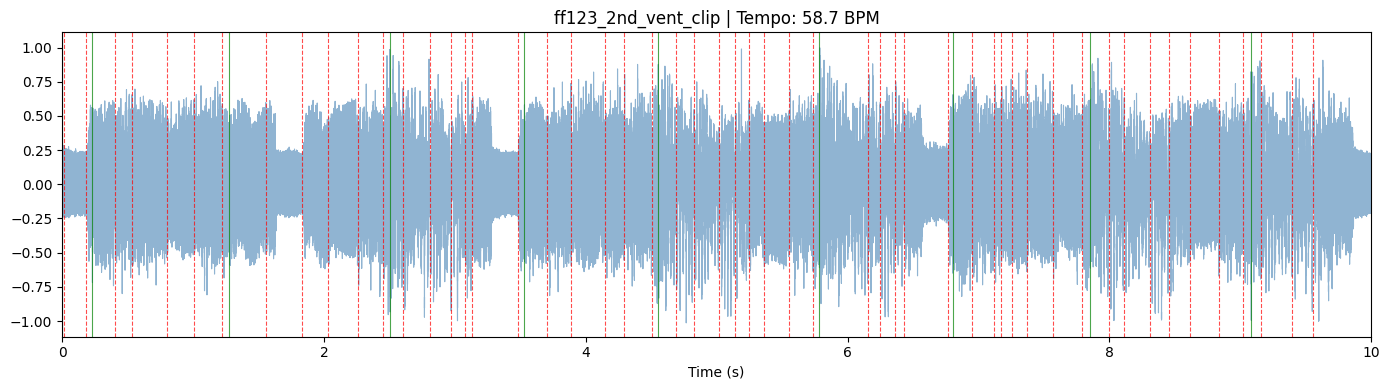

In [15]:
# Visualize results
def visualize(wav_path, onsets, beats, tempos, title=""):
    y, sr = librosa.load(wav_path, sr=config.audio.sample_rate)
    time = np.arange(len(y)) / sr
    
    plt.figure(figsize=(14, 4))
    plt.plot(time, y, alpha=0.6, color='steelblue', linewidth=0.8)
    for o in onsets:
        plt.axvline(x=o, color='red', alpha=0.7, linewidth=0.8, linestyle='--')
    for b in beats:
        plt.axvline(x=b, color='green', alpha=0.7, linewidth=0.8)
    plt.xlabel('Time (s)')
    plt.title(f'{title} | Tempo: {tempos[0]:.1f} BPM')
    plt.xlim(0, min(10, time[-1]))
    plt.tight_layout()
    plt.show()

if val_items:
    stem = list(val_items.keys())[0]
    gt = val_items[stem]
    pred = val_predictions[stem]
    print(f"File: {stem}")
    print(f"GT onsets: {len(gt['onsets'])} | Pred: {len(pred['onsets'])}")
    print(f"GT beats: {len(gt['beats'])} | Pred: {len(pred['beats'])}")
    print(f"GT tempo: {gt['tempo']} | Pred: {pred['tempo']}")
    visualize(gt['wav'], pred['onsets'], pred['beats'], pred['tempo'], stem)

In [16]:
# Sweep — parameter search (restores config on exit)
_saved_threshold = config.onset.threshold
_saved_method = config.onset.method


def run_sweep(thresholds):
    results = []
    for thresh in thresholds:
        config.onset.threshold = thresh
        pipeline_sw = Pipeline()

        preds = {}
        for stem, info in val_items.items():
            y, sr = loader.load_audio(info['wav'])
            if y is None:
                continue
            o, b, t = pipeline_sw.process_file(y, sr)
            preds[stem] = {'onsets': o.tolist(), 'beats': b.tolist(), 'tempo': t}

        onset_f1s, beat_f1s, tempo_sc = [], [], []
        for stem, gt in val_items.items():
            if stem not in preds:
                continue
            pred = preds[stem]
            if gt.get('onsets') and pred.get('onsets'):
                f, _, _ = mir_eval.onset.f_measure(
                    np.array(gt['onsets']), np.array(pred['onsets']), window=0.05
                )
                onset_f1s.append(f)
            if gt.get('beats') and pred.get('beats'):
                f = mir_eval.beat.f_measure(np.array(gt['beats']), np.array(pred['beats']))
                beat_f1s.append(f)
            if gt.get('tempo') and pred.get('tempo'):
                gt_tempo = gt['tempo']
                if len(gt_tempo) == 1:
                    ref_tempi = np.array([gt_tempo[0] / 2, gt_tempo[0]])
                    ref_weight = 0.5
                elif len(gt_tempo) == 2:
                    ref_tempi = np.array(gt_tempo)
                    ref_weight = 0.5
                elif len(gt_tempo) >= 3:
                    ref_tempi = np.array(gt_tempo[:2])
                    ref_weight = gt_tempo[2]
                else:
                    continue
                est_tempi = np.array(pred['tempo'][:2])
                try:
                    p_score = mir_eval.tempo.detection(ref_tempi, ref_weight, est_tempi, tol=0.08)
                    tempo_sc.append(p_score)
                except Exception:
                    pass

        mean_onset = np.mean(onset_f1s) if onset_f1s else 0
        mean_beat = np.mean(beat_f1s) if beat_f1s else 0
        mean_tempo = np.mean(tempo_sc) if tempo_sc else 0
        overall = (mean_onset + mean_beat + mean_tempo) / 3
        results.append({'threshold': thresh, 'onset_f1': mean_onset, 'beat_f1': mean_beat,
                        'tempo': mean_tempo, 'overall': overall})
        print(f"thresh={thresh:.4f}: Onset={mean_onset:.4f}, Beat={mean_beat:.4f}, "
              f"Tempo={mean_tempo:.4f}, Overall={overall:.4f}")

    if results:
        best = max(results, key=lambda x: x['overall'])
        print(f"\nBEST: threshold={best['threshold']}")
        print(f"  Onset F1: {best['onset_f1']:.4f}  Beat F1: {best['beat_f1']:.4f}  "
              f"Tempo: {best['tempo']:.4f}  Overall: {best['overall']:.4f}")
    return results


thresholds = [0.08, 0.04, 0.03, 0.02, 0.01, 0.005]
results = run_sweep(thresholds)

# Restore config
config.onset.threshold = _saved_threshold
config.onset.method = _saved_method
print(f"\nConfig restored: threshold={config.onset.threshold}, method={config.onset.method}")

thresh=0.0800: Onset=0.6187, Beat=0.4960, Tempo=0.5844, Overall=0.5664
thresh=0.0400: Onset=0.7313, Beat=0.4960, Tempo=0.5844, Overall=0.6039
thresh=0.0300: Onset=0.7557, Beat=0.4960, Tempo=0.5844, Overall=0.6120
thresh=0.0200: Onset=0.7772, Beat=0.4960, Tempo=0.5844, Overall=0.6192
thresh=0.0100: Onset=0.7858, Beat=0.4960, Tempo=0.5844, Overall=0.6221
thresh=0.0050: Onset=0.7757, Beat=0.4960, Tempo=0.5844, Overall=0.6187

BEST: threshold=0.01
  Onset F1: 0.7858  Beat F1: 0.4960  Tempo: 0.5844  Overall: 0.6221

Config restored: threshold=0.011, method=superflux
